<a href="https://colab.research.google.com/github/guicamargu/analise-consumo-alimenticio-2019-2025/blob/main/notebooks/analise_consumo_alimenticio_2019_2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise de Consumo Alimentício (2019–2025)

Autores:
- Guilherme de Oliveira Camargo
- Thiago Araújo Costa

Trabalho de Conclusão de Curso (TCC) em Ciência da Computação.

Objetivo: analisar tendências de consumo no setor alimentício brasileiro entre 2019 e 2025, avaliando os impactos da pandemia de COVID-19 e possíveis perspectivas futuras para o mercado.

In [44]:
from pathlib import Path
import subprocess
import sys

REPO_URL = "https://github.com/guicamargu/analise-consumo-alimenticio-2019-2025.git"
REPO_NAME = "analise-consumo-alimenticio-2019-2025"

# Detecta se está rodando no Google Colab
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    repo_path = Path("/content") / REPO_NAME

    if not repo_path.exists():
        subprocess.run(["git", "clone", REPO_URL, str(repo_path)], check=True)

    BASE_DIR = repo_path
else:
    # Caso rode localmente dentro da pasta notebooks
    BASE_DIR = Path("..").resolve()

DADOS_DIR = BASE_DIR / "dados"

print("Pasta de dados:", DADOS_DIR)

Pasta de dados: /content/analise-consumo-alimenticio-2019-2025/dados


In [45]:
import pandas as pd

arquivo = DADOS_DIR / "tabela8882.csv"

dados = pd.read_csv(
    arquivo,
    sep=";",
    encoding="utf-8-sig",
    skiprows=3
)

dados.head()

,Unnamed: 0,Atividades,janeiro 2019,fevereiro 2019,março 2019,abril 2019,maio 2019,junho 2019,julho 2019,agosto 2019,...,março 2025,abril 2025,maio 2025,junho 2025,julho 2025,agosto 2025,setembro 2025,outubro 2025,novembro 2025,dezembro 2025
0,NaN,Atividades,Índice de volume de vendas no comércio varejista,Índice de volume de vendas no comércio varejista,Índice de volume de vendas no comércio varejista,Índice de volume de vendas no comércio varejista,Índice de volume de vendas no comércio varejista,Índice de volume de vendas no comércio varejista,Índice de volume de vendas no comércio varejista,Índice de volume de vendas no comércio varejista,...,Índice de volume de vendas no comércio varejista,Índice de volume de vendas no comércio varejista,Índice de volume de vendas no comércio varejista,Índice de volume de vendas no comércio varejista,Índice de volume de vendas no comércio varejista,Índice de volume de vendas no comércio varejista,Índice de volume de vendas no comércio varejista,Índice de volume de vendas no comércio varejista,Índice de volume de vendas no comércio varejista,Índice de volume de vendas no comércio varejista
1,Brasil,"Hipermercados, supermercados, produtos aliment...","96,47752","90,75268","94,37610","93,30936","93,46582","91,40297","93,14186","99,22104",...,"108,94951","109,38155","109,36831","102,91958","107,07890","110,72470","104,80687","110,43216","112,98795","128,87705"
2,Brasil,Hipermercados e supermercados,"95,54743","89,64694","93,06886","92,21864","92,10576","89,65830","91,35823","97,67820",...,"110,04474","111,12142","110,54340","103,88618","108,23723","112,19433","106,15169","111,75774","114,65711","130,44854"
3,Fonte: IBGE - Pesquisa Mensal de Comércio,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [46]:
import pandas as pd
import matplotlib.pyplot as plt

arquivo = DADOS_DIR / "tabela8882.csv"

# Lê o CSV do SIDRA
bruto = pd.read_csv(
    arquivo,
    sep=";",
    encoding="utf-8-sig",
    skiprows=3
)

# Mantém apenas as linhas reais de dados, removendo cabeçalho repetido, fonte e linhas vazias
dados_setores = bruto[bruto["Atividades"].isin([
    "Hipermercados, supermercados, produtos alimentícios, bebidas e fumo",
    "Hipermercados e supermercados"
])].copy()

# Transforma meses que estão em colunas em linhas
dados_longos = dados_setores.melt(
    id_vars=["Unnamed: 0", "Atividades"],
    var_name="Mes_Ano",
    value_name="Indice"
)

# Renomeia a coluna de território
dados_longos = dados_longos.rename(columns={"Unnamed: 0": "Territorio"})

# Remove linhas que não são meses
dados_longos = dados_longos[dados_longos["Mes_Ano"].str.contains("2019|2020|2021|2022|2023|2024|2025", na=False)]

# Converte valores brasileiros com vírgula para número
dados_longos["Indice"] = (
    dados_longos["Indice"]
    .astype(str)
    .str.replace(",", ".", regex=False)
    .astype(float)
)

# Cria uma data real para ordenar corretamente
meses = {
    "janeiro": "01", "fevereiro": "02", "março": "03", "abril": "04",
    "maio": "05", "junho": "06", "julho": "07", "agosto": "08",
    "setembro": "09", "outubro": "10", "novembro": "11", "dezembro": "12"
}

def converter_data(texto):
    partes = texto.split()
    mes = meses[partes[0]]
    ano = partes[1]
    return pd.to_datetime(f"{ano}-{mes}-01")

dados_longos["Data"] = dados_longos["Mes_Ano"].apply(converter_data)
dados_longos["Ano"] = dados_longos["Data"].dt.year

dados_longos.head()

,Territorio,Atividades,Mes_Ano,Indice,Data,Ano
0,Brasil,"Hipermercados, supermercados, produtos aliment...",janeiro 2019,96.47752,2019-01-01,2019
1,Brasil,Hipermercados e supermercados,janeiro 2019,95.54743,2019-01-01,2019
2,Brasil,"Hipermercados, supermercados, produtos aliment...",fevereiro 2019,90.75268,2019-02-01,2019
3,Brasil,Hipermercados e supermercados,fevereiro 2019,89.64694,2019-02-01,2019
4,Brasil,"Hipermercados, supermercados, produtos aliment...",março 2019,94.37610,2019-03-01,2019


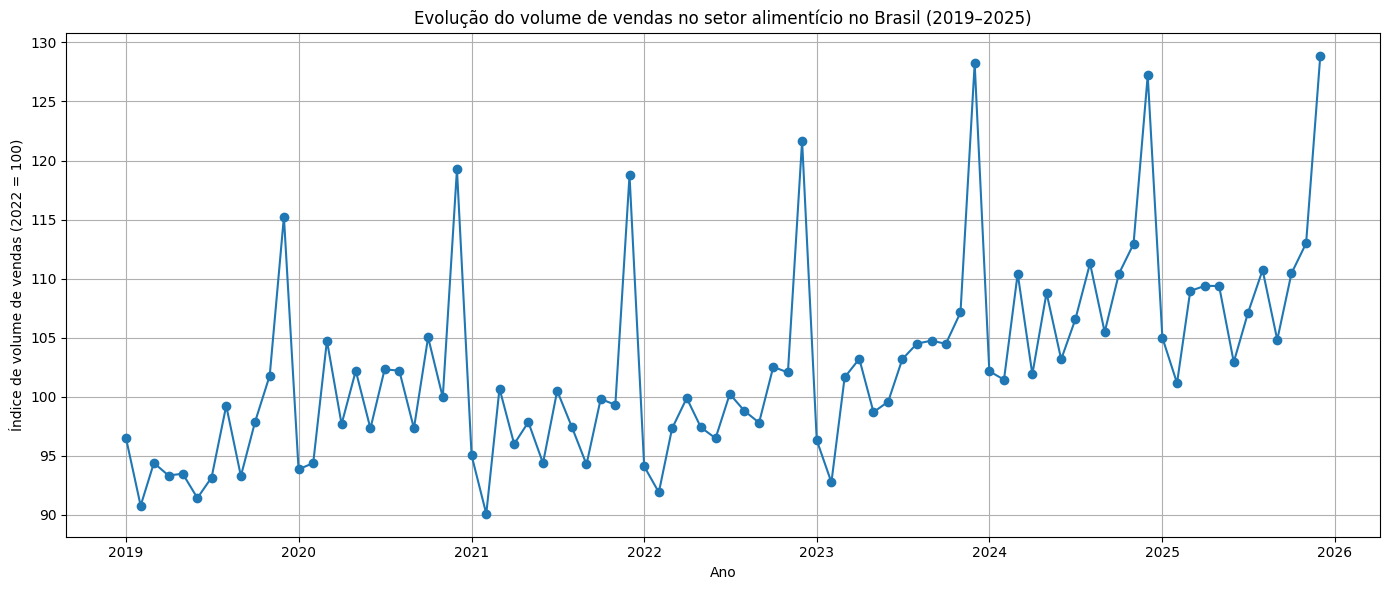

In [47]:
import matplotlib.pyplot as plt

# Filtra apenas o setor mais completo
setor_alimentos = dados_longos[
    dados_longos["Atividades"] == "Hipermercados, supermercados, produtos alimentícios, bebidas e fumo"
].copy()

# Ordena pela data
setor_alimentos = setor_alimentos.sort_values("Data")

# Cria o gráfico
plt.figure(figsize=(14, 6))
plt.plot(setor_alimentos["Data"], setor_alimentos["Indice"], marker="o")

plt.title("Evolução do volume de vendas no setor alimentício no Brasil (2019–2025)")
plt.xlabel("Ano")
plt.ylabel("Índice de volume de vendas (2022 = 100)")
plt.grid(True)
plt.tight_layout()

plt.show()

In [48]:
# Média por ano

media_por_ano = (
    setor_alimentos
    .groupby("Ano")["Indice"]
    .mean()
)

print(media_por_ano)

Ano
2019     96.690567
2020    101.340750
2021     98.660871
2022    100.000000
2023    103.692682
2024    108.470669
2025    109.304924
Name: Indice, dtype: float64


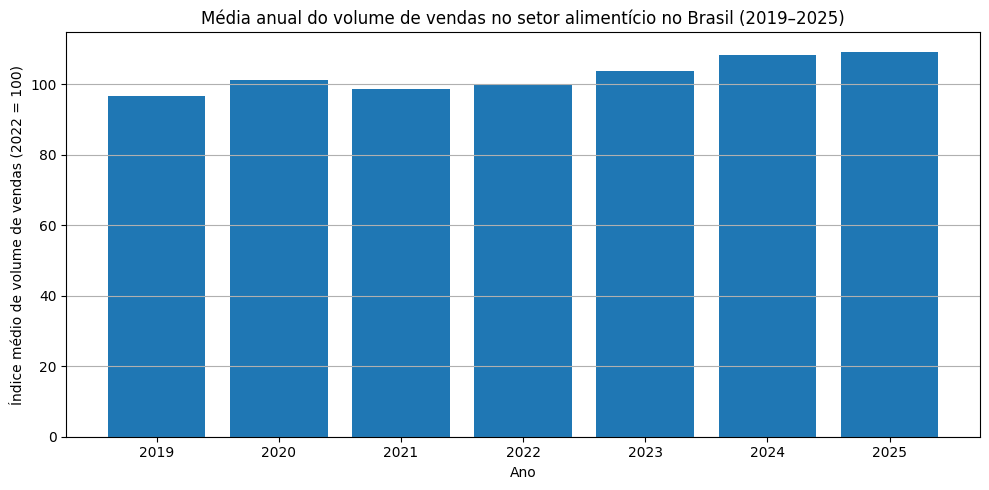

In [49]:
# Gráfico da média anual do setor alimentício

plt.figure(figsize=(10, 5))
plt.bar(media_por_ano.index.astype(str), media_por_ano.values)

plt.title("Média anual do volume de vendas no setor alimentício no Brasil (2019–2025)")
plt.xlabel("Ano")
plt.ylabel("Índice médio de volume de vendas (2022 = 100)")
plt.grid(axis="y")
plt.tight_layout()

plt.show()

In [50]:
# Classificação dos períodos analisados

def classificar_periodo(ano):
    if ano == 2019:
        return "Pré-pandemia"
    elif ano in [2020, 2021]:
        return "Pandemia"
    else:
        return "Pós-pandemia"

setor_alimentos["Periodo"] = setor_alimentos["Ano"].apply(classificar_periodo)

media_por_periodo = (
    setor_alimentos
    .groupby("Periodo")["Indice"]
    .mean()
    .reindex(["Pré-pandemia", "Pandemia", "Pós-pandemia"])
)

print(media_por_periodo)

Periodo
Pré-pandemia     96.690567
Pandemia        100.000810
Pós-pandemia    105.367069
Name: Indice, dtype: float64


In [51]:
variacao = ((105.367069 - 96.690567) / 96.690567) * 100
print(variacao)

8.973473079333582


In [52]:
# Tabela analítica anual com indicadores derivados

analise_anual = media_por_ano.reset_index()
analise_anual.columns = ["Ano", "Indice_medio"]

# Índice de referência: ano pré-pandemia
indice_2019 = analise_anual.loc[analise_anual["Ano"] == 2019, "Indice_medio"].values[0]

# Variação em relação a 2019
analise_anual["Variacao_vs_2019_%"] = ((analise_anual["Indice_medio"] - indice_2019) / indice_2019) * 100

# Variação em relação ao ano anterior
analise_anual["Variacao_ano_anterior_%"] = analise_anual["Indice_medio"].pct_change() * 100

# Arredondamento para melhor visualização
analise_anual = analise_anual.round(2)

analise_anual

,Ano,Indice_medio,Variacao_vs_2019_%,Variacao_ano_anterior_%
0,2019,96.69,0.00,NaN
1,2020,101.34,4.81,4.81
2,2021,98.66,2.04,-2.64
3,2022,100.00,3.42,1.36
4,2023,103.69,7.24,3.69
5,2024,108.47,12.18,4.61
6,2025,109.30,13.05,0.77


In [53]:
# Comparação entre os dois setores disponíveis na base

media_setores_ano = (
    dados_longos
    .groupby(["Ano", "Atividades"])["Indice"]
    .mean()
    .reset_index()
)

media_setores_ano.head()

,Ano,Atividades,Indice
0,2019,Hipermercados e supermercados,95.293023
1,2019,"Hipermercados, supermercados, produtos aliment...",96.690567
2,2020,Hipermercados e supermercados,100.994437
3,2020,"Hipermercados, supermercados, produtos aliment...",101.340750
4,2021,Hipermercados e supermercados,98.570009


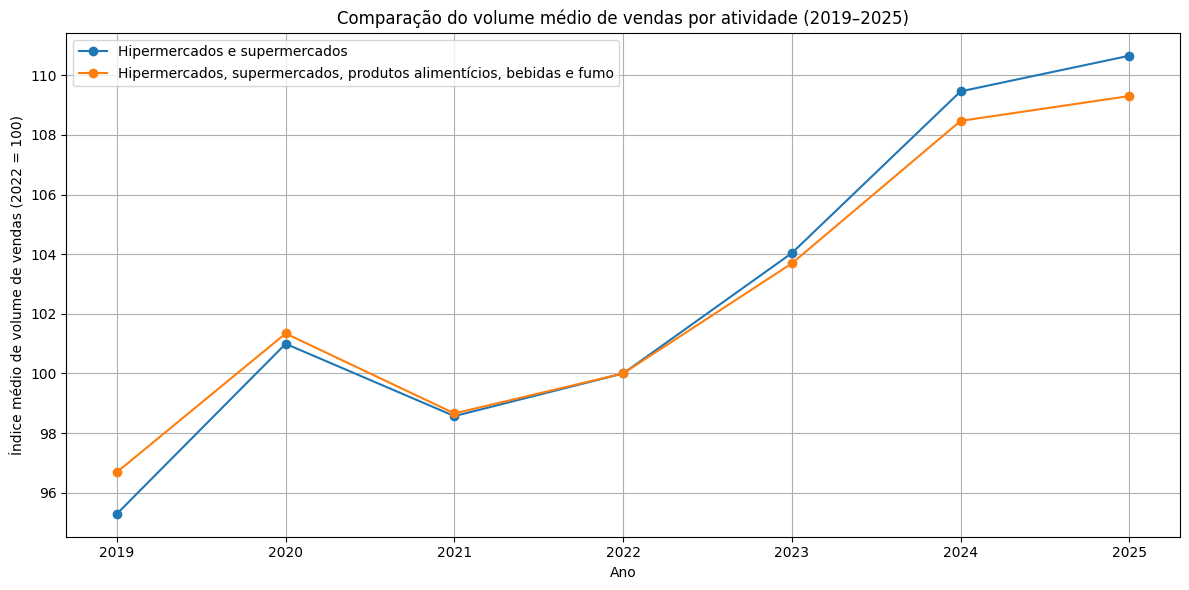

In [54]:
# Gráfico comparativo entre setores

plt.figure(figsize=(12, 6))

for atividade in media_setores_ano["Atividades"].unique():
    dados_atividade = media_setores_ano[media_setores_ano["Atividades"] == atividade]
    plt.plot(
        dados_atividade["Ano"],
        dados_atividade["Indice"],
        marker="o",
        label=atividade
    )

plt.title("Comparação do volume médio de vendas por atividade (2019–2025)")
plt.xlabel("Ano")
plt.ylabel("Índice médio de volume de vendas (2022 = 100)")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

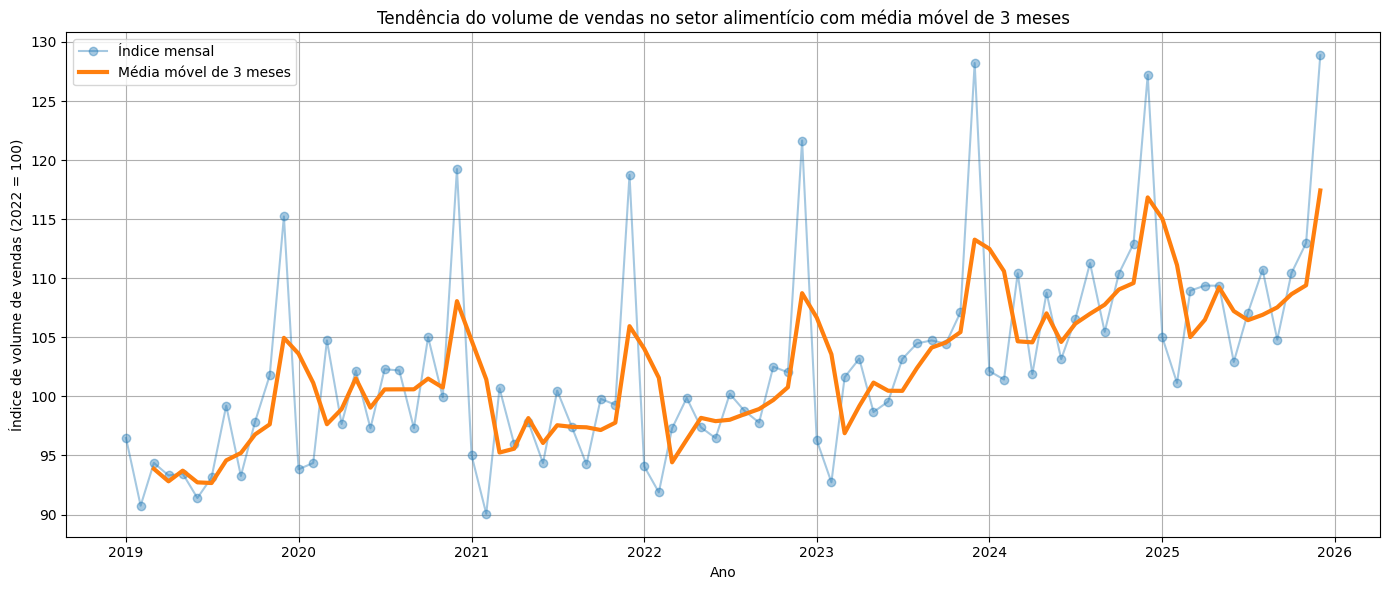

In [55]:
# Média móvel de 3 meses para suavizar oscilações mensais

setor_alimentos = setor_alimentos.sort_values("Data")

setor_alimentos["Media_movel_3m"] = (
    setor_alimentos["Indice"]
    .rolling(window=3)
    .mean()
)

plt.figure(figsize=(14, 6))

plt.plot(
    setor_alimentos["Data"],
    setor_alimentos["Indice"],
    alpha=0.4,
    marker="o",
    label="Índice mensal"
)

plt.plot(
    setor_alimentos["Data"],
    setor_alimentos["Media_movel_3m"],
    linewidth=3,
    label="Média móvel de 3 meses"
)

plt.title("Tendência do volume de vendas no setor alimentício com média móvel de 3 meses")
plt.xlabel("Ano")
plt.ylabel("Índice de volume de vendas (2022 = 100)")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

In [56]:
# Análise de sazonalidade: média histórica por mês

setor_alimentos["Mes"] = setor_alimentos["Data"].dt.month

media_por_mes = (
    setor_alimentos
    .groupby("Mes")["Indice"]
    .mean()
    .reset_index()
)

nomes_meses = {
    1: "Jan", 2: "Fev", 3: "Mar", 4: "Abr",
    5: "Mai", 6: "Jun", 7: "Jul", 8: "Ago",
    9: "Set", 10: "Out", 11: "Nov", 12: "Dez"
}

media_por_mes["Mes_nome"] = media_por_mes["Mes"].map(nomes_meses)

media_por_mes

,Mes,Indice,Mes_nome
0,1,97.549317,Jan
1,2,94.623923,Fev
2,3,102.584583,Mar
3,4,100.184221,Abr
4,5,101.099663,Mai
5,6,97.880764,Jun
6,7,101.849816,Jul
7,8,103.446429,Ago
8,9,99.659646,Set
9,10,104.354559,Out


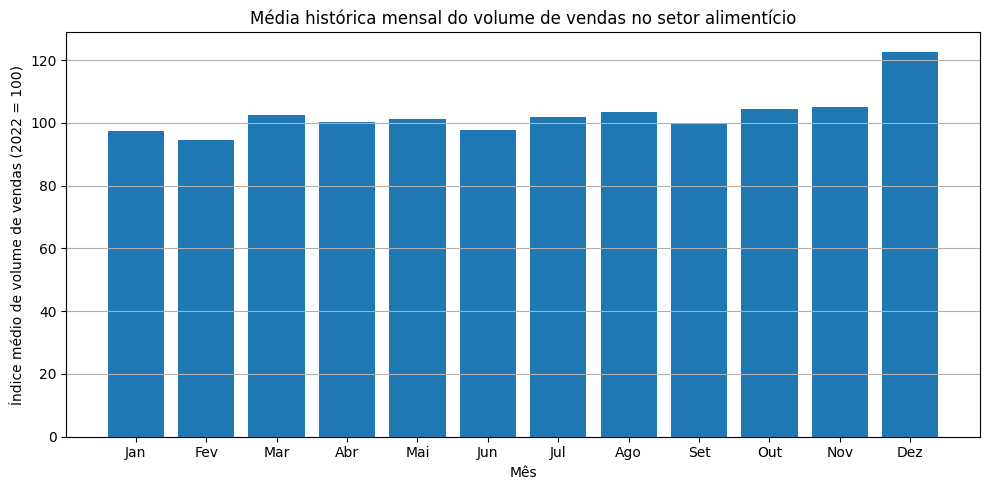

In [57]:
# Gráfico da média histórica por mês

plt.figure(figsize=(10, 5))
plt.bar(media_por_mes["Mes_nome"], media_por_mes["Indice"])

plt.title("Média histórica mensal do volume de vendas no setor alimentício")
plt.xlabel("Mês")
plt.ylabel("Índice médio de volume de vendas (2022 = 100)")
plt.grid(axis="y")
plt.tight_layout()

plt.show()

In [58]:
dados_longos.to_csv(DADOS_DIR / "base_tratada_ibge.csv", index=False, encoding="utf-8-sig")
analise_anual.to_csv(DADOS_DIR / "analise_anual_setor_alimenticio.csv", index=False, encoding="utf-8-sig")
media_por_mes.to_csv(DADOS_DIR / "sazonalidade_mensal_setor_alimenticio.csv", index=False, encoding="utf-8-sig")

print("Arquivos exportados com sucesso!")

Arquivos exportados com sucesso!
